In [1]:
# Enable Logging

import logging
import pandas as pd
from pathlib import Path

# --------------------------------------------------
# Create logs folder if it does not exist
# --------------------------------------------------
LOG_DIR = Path("../logs")
LOG_DIR.mkdir(parents=True, exist_ok=True)

LOG_FILE = LOG_DIR / "store_sales_deep_learning.log"

# --------------------------------------------------
# Create logger
# --------------------------------------------------
logger = logging.getLogger("StoreSales_deep_learning")
logger.setLevel(logging.DEBUG)

# Prevent duplicate handlers if this cell is run again
if logger.hasHandlers():
    logger.handlers.clear()

# --------------------------------------------------
# Console handler
# --------------------------------------------------
console_handler = logging.StreamHandler()
console_handler.setLevel(logging.DEBUG)

# --------------------------------------------------
# File handler
# --------------------------------------------------
file_handler = logging.FileHandler(
    LOG_FILE,
    mode="a",
    encoding="utf-8"
)
file_handler.setLevel(logging.DEBUG)

# --------------------------------------------------
# Formatter
# --------------------------------------------------
formatter = logging.Formatter(
    "%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)

console_handler.setFormatter(formatter)
file_handler.setFormatter(formatter)

# --------------------------------------------------
# Add handlers
# --------------------------------------------------
logger.addHandler(console_handler)
logger.addHandler(file_handler)

# --------------------------------------------------
# First log message
# --------------------------------------------------
logger.info("Store Sales Deep Learning - ACF/PACF TimeSeries notebook started.")

print(f"Logging enabled: {LOG_FILE.resolve()}")

2026-09-14 22:04:04,266 - StoreSales_deep_learning - INFO - Store Sales Deep Learning - ACF/PACF TimeSeries notebook started.


Logging enabled: C:\Users\AMOGH\Desktop\Nexthikes_Projects\Project6_Sales Forecasting_DL\rossmann-store-sales\Store_Sales_Project\logs\store_sales_deep_learning.log


In [2]:
# Load the feature-engineered data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

store_train = pd.read_csv(
    "../data/feature_engineered_store_train.csv"
)

store_test = pd.read_csv(
    "../data/feature_engineered_store_test.csv"
)

# Convert Date back to datetime
store_train["Date"] = pd.to_datetime(store_train["Date"])
store_test["Date"] = pd.to_datetime(store_test["Date"])
print("Train Shape:", store_train.shape)
print("Test Shape:", store_test.shape)
print("\nDate Range:")
print("Start:", store_train["Date"].min())
print("End:", store_train["Date"].max())

C:\Users\AMOGH\AppData\Local\Temp\ipykernel_20360\1477052563.py:6: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  store_train = pd.read_csv(
C:\Users\AMOGH\AppData\Local\Temp\ipykernel_20360\1477052563.py:10: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  store_test = pd.read_csv(


Train Shape: (1017209, 28)
Test Shape: (41088, 27)

Date Range:
Start: 2013-01-01 00:00:00
End: 2015-07-31 00:00:00


In [3]:
# Reload issue with PromoInterval, so fixing it again if necessary:
store_train["PromoInterval"] = (
    store_train["PromoInterval"].fillna("NoPromo")
)

store_test["PromoInterval"] = (
    store_test["PromoInterval"].fillna("NoPromo")
)

print("Train missing:", store_train.isnull().sum().sum())
print("Test missing:", store_test.isnull().sum().sum())

Train missing: 0
Test missing: 0


In [4]:
# Sort chronologically - This is essential for time-series work.
logger.info("Sorted Store,Date,Sales data chronologically - This is essential for time-series work.")
store_train = store_train.sort_values(
    by=["Store", "Date"]
).reset_index(drop=True)
store_test = store_test.sort_values(
    by=["Store", "Date"]
).reset_index(drop=True)
print(
    store_train[
        ["Store", "Date", "Sales"]
    ].head(10)
)

2026-09-14 22:05:09,210 - StoreSales_deep_learning - INFO - Sorted Store,Date,Sales data chronologically - This is essential for time-series work.


   Store       Date  Sales
0      1 2013-01-01      0
1      1 2013-01-02   5530
2      1 2013-01-03   4327
3      1 2013-01-04   4486
4      1 2013-01-05   4997
5      1 2013-01-06      0
6      1 2013-01-07   7176
7      1 2013-01-08   5580
8      1 2013-01-09   5471
9      1 2013-01-10   4892


In [6]:
# Create aggregate daily sales series. Because we have 1,115 stores and we don't immediately run ACF/PACF and ARIMA separately 1,115 times.
logger.info("Created aggregate daily sales series to avoid ACF/PACF and ARIMA separately for each store.")
daily_sales = (
    store_train
    .groupby("Date")["Sales"]
    .sum()
    .sort_index()
)
print(daily_sales.head())
print("\nNumber of days:", len(daily_sales))

2026-09-14 22:05:21,584 - StoreSales_deep_learning - INFO - Created aggregate daily sales series to avoid ACF/PACF and ARIMA separately for each store.


Date
2013-01-01      97235
2013-01-02    6949829
2013-01-03    6347820
2013-01-04    6638954
2013-01-05    5951593
Name: Sales, dtype: int64

Number of days: 942


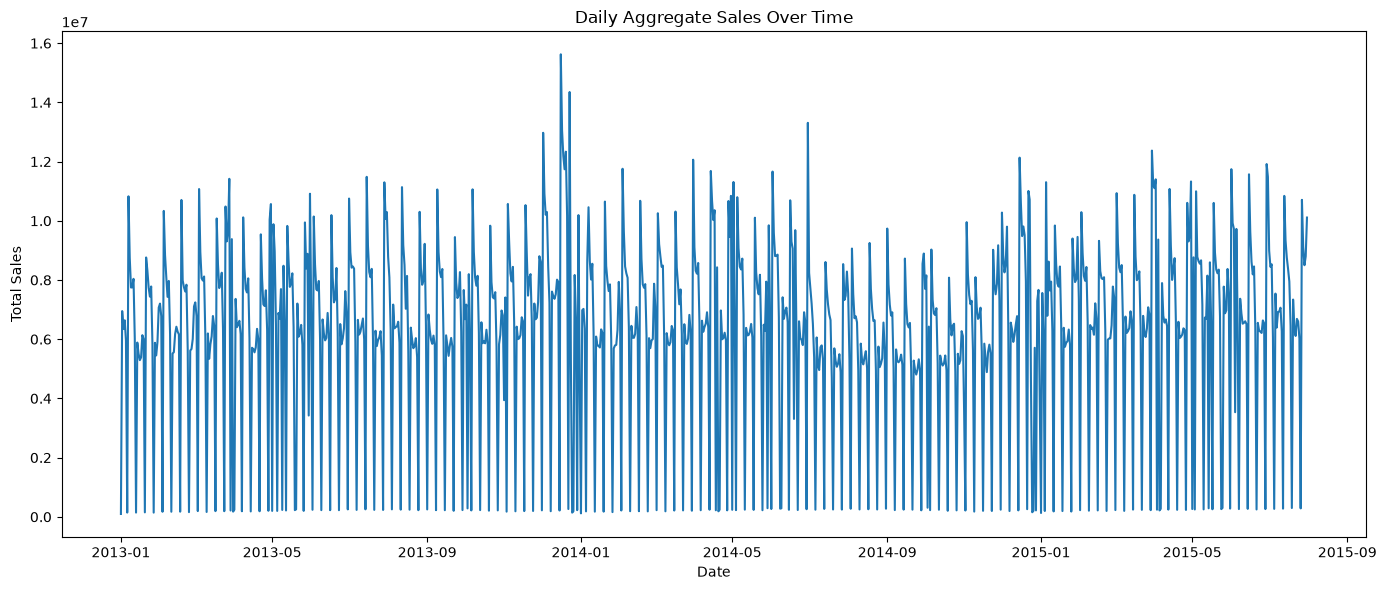

In [7]:
# Plot
plt.figure(figsize=(14, 6))
plt.plot(
    daily_sales.index,
    daily_sales.values
)
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Daily Aggregate Sales Over Time")
plt.tight_layout()
plt.show()

In [8]:
# Stationarity test - Before ARIMA/SARIMA, checking whether the sales series is stationary using the Augmented Dickey-Fuller (ADF) test.
logger.info("Performed Stationarity test - Before ARIMA/SARIMA using ADF")
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(
    daily_sales.dropna()
)
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

2026-09-14 22:05:31,952 - StoreSales_deep_learning - INFO - Performed Stationarity test - Before ARIMA/SARIMA using ADF


ADF Statistic: -4.761614524595631
p-value: 6.436731330558898e-05

Critical Values:
1%: -3.437470108019385
5%: -2.8646832620852853
10%: -2.5684436698650503


C:\Users\AMOGH\AppData\Local\Temp\ipykernel_20360\466884211.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(


In [9]:
# Interpret : The basic rule is: p-value ≤ 0.05 is stationary and if p-value > 0.05 is non-stationary
if adf_result[1] <= 0.05:
    print("The time series is stationary.")
    logger.info("The time series is stationary.")
else:
    print("The time series is non-stationary.")
    logger.info("The time series is non-stationary.")

2026-09-14 22:05:45,186 - StoreSales_deep_learning - INFO - The time series is stationary.


The time series is stationary.


In [14]:
# ADF Result: The ADF statistic is -4.7616 and the p-value is approximately 0.000064, which is less than the significance level of 0.05.
# p-value is:  6.436731330559343 \times 10^{-5} which in decimal form is approximately:0.00006437 , So: 0.00006437 < 0.05

<Figure size 1200x500 with 0 Axes>

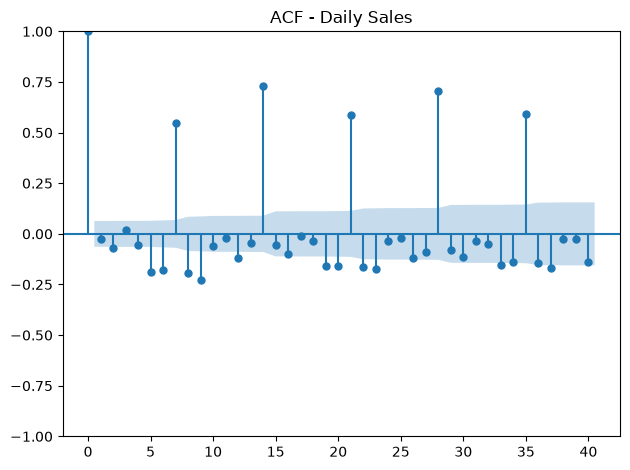

In [10]:
# ACF and PACF
from statsmodels.graphics.tsaplots import (
    plot_acf,
    plot_pacf
)
plt.figure(figsize=(12, 5))
plot_acf(
    daily_sales.dropna(),
    lags=40
)
plt.title("ACF - Daily Sales")
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

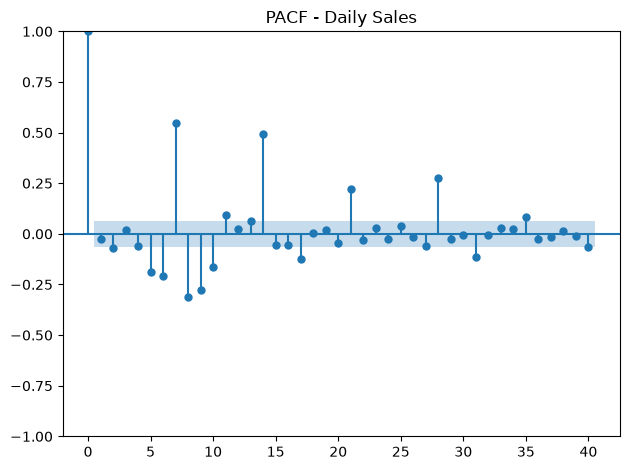

In [11]:
# Then PACF:

plt.figure(figsize=(12, 5))
plot_pacf(
    daily_sales.dropna(),
    lags=40,
    method="ywm"
)
plt.title("PACF - Daily Sales")
plt.tight_layout()
plt.show()

In [ ]:
# ADF statistic is −4.7616, which is more negative than even the 1% critical value (−3.4375), and the p-value is 0.000064, far below 0.05.
# Therefore, we reject the null hypothesis of a unit root.
# For the aggregate daily-sales series, we can initially use d = 0 for ARIMA rather than automatically differencing it.
# ACF/PACF plots also show something very important: there are strong spikes around lags 7, 14, 21, 28, and 35.
# That's a clear sign of a weekly seasonal pattern in daily sales. 
# This will matter especially when we reach SARIMA, where seasonal period s = 7 is a sensible candidate.

In [12]:
# Sliding-Window Supervised Transform
# Starting the LSTM/GRU track.
# We'll use past sales values to predict future sales. A 7-day window is a sensible starting point because ACF/PACF analysis shows strong weekly behavior.
# First creating the series:-
sales_values = daily_sales.values.reshape(-1, 1)
print("Sales data shape:", sales_values.shape)
print(sales_values[:10])

Sales data shape: (942, 1)
[[   97235]
 [ 6949829]
 [ 6347820]
 [ 6638954]
 [ 5951593]
 [  143904]
 [10826848]
 [ 8749437]
 [ 7746603]
 [ 7751485]]


In [13]:
# Scale to (-1, 1)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(
    feature_range=(-1, 1)
)
sales_scaled = scaler.fit_transform(
    sales_values
)
print("Scaled minimum:", sales_scaled.min())
print("Scaled maximum:", sales_scaled.max())

Scaled minimum: -1.0
Scaled maximum: 1.0


In [14]:
# Create sliding windows
# We'll use the previous 7 days to predict the next day.
def create_sequences(data, window_size=7):
    X = []
    y = []
    for i in range(len(data) - window_size):
        X.append(
            data[i:i + window_size]
        )
        y.append(
            data[i + window_size]
        )
    return np.array(X), np.array(y)
window_size = 7
X_seq, y_seq = create_sequences(
    sales_scaled,
    window_size
)
print("X shape:", X_seq.shape)
print("y shape:", y_seq.shape)
# Structure - (samples, time_steps, features)
# Here, 7 = previous seven days and 1 = Sales feature.

X shape: (935, 7, 1)
y shape: (935, 1)


In [15]:
# Chronological train/test split
# For LSTM, not using train_test_split(..., random_state=42). Time-series observations must stay in chronological order.
split_index = int(
    len(X_seq) * 0.80
)
X_train_lstm = X_seq[:split_index]
X_test_lstm = X_seq[split_index:]
y_train_lstm = y_seq[:split_index]
y_test_lstm = y_seq[split_index:]
print("Training X:", X_train_lstm.shape)
print("Training y:", y_train_lstm.shape)
print("Testing X:", X_test_lstm.shape)
print("Testing y:", y_test_lstm.shape)

Training X: (748, 7, 1)
Training y: (748, 1)
Testing X: (187, 7, 1)
Testing y: (187, 1)


In [16]:
# The required 2-layer LSTM model in Keras.
logger.info("Building a 2-layer LSTM model in Keras....")
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
lstm_model = Sequential([
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])
    ),
    Dropout(0.2),
    LSTM(
        32,
        return_sequences=False
    ),
    Dropout(0.2),
    Dense(1)
])
lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)
lstm_model.summary()
logger.info("Finished 2-layer LSTM Model !")

2026-09-14 22:06:36,572 - StoreSales_deep_learning - INFO - Building a 2-layer LSTM model in Keras....


c:\Users\AMOGH\Desktop\Nexthikes_Projects\Project6_Sales Forecasting_DL\rossmann-store-sales\Store_Sales_Project\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

2026-09-14 22:06:43,881 - StoreSales_deep_learning - INFO - Finished 2-layer LSTM Model !


In [17]:
# Now training it:
logger.info("Training a LSTM model....")
history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)
logger.info("Finished Training LSTM !")

2026-09-14 22:07:01,384 - StoreSales_deep_learning - INFO - Training a LSTM model....


Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - loss: 0.1733 - mae: 0.2976 - val_loss: 0.1397 - val_mae: 0.2815
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1616 - mae: 0.2983 - val_loss: 0.1481 - val_mae: 0.2787
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.1585 - mae: 0.2934 - val_loss: 0.1377 - val_mae: 0.2770
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1529 - mae: 0.2959 - val_loss: 0.1308 - val_mae: 0.2752
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1415 - mae: 0.2970 - val_loss: 0.1118 - val_mae: 0.2764
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1259 - mae: 0.2867 - val_loss: 0.1089 - val_mae: 0.2703
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.1161 - mae: 0.2671 - val_loss: 0.1117 - val_mae: 0.2667
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1098 - mae: 0.2533 - val_loss: 0.1013 - val_mae: 0.2545
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.098

2026-09-14 22:07:25,378 - StoreSales_deep_learning - INFO - Finished Training LSTM !


In [18]:
# After training, evaluating:
logger.info("Evaluating LSTM....")
lstm_loss, lstm_mae_scaled = lstm_model.evaluate(
    X_test_lstm,
    y_test_lstm,
    verbose=0
)
print("LSTM Test Loss:", lstm_loss)
print("LSTM MAE (Scaled):", lstm_mae_scaled)
logger.debug(f"LSTM Test Loss: {lstm_loss}")
logger.debug(f"LSTM MAE (Scaled): {lstm_mae_scaled}")
logger.info("Evaluation Done !")

2026-09-14 22:07:31,886 - StoreSales_deep_learning - INFO - Evaluating LSTM....
2026-09-14 22:07:32,038 - StoreSales_deep_learning - DEBUG - LSTM Test Loss: 0.07524837553501129
2026-09-14 22:07:32,039 - StoreSales_deep_learning - DEBUG - LSTM MAE (Scaled): 0.1728021502494812
2026-09-14 22:07:32,040 - StoreSales_deep_learning - INFO - Evaluation Done !


LSTM Test Loss: 0.07524837553501129
LSTM MAE (Scaled): 0.1728021502494812


In [19]:
# Then generating predictions:
lstm_predictions_scaled = lstm_model.predict(
    X_test_lstm
)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


In [20]:
# Because the data was scaled to (-1, 1), convert predictions and actual values back to original sales:
lstm_predictions = scaler.inverse_transform(
    lstm_predictions_scaled
)
y_test_actual = scaler.inverse_transform(
    y_test_lstm
)
print("Actual Sales:")
print(y_test_actual[:5])
print("\nPredicted Sales:")
print(lstm_predictions[:5])

Actual Sales:
[[9401803.]
 [8392342.]
 [7930037.]
 [8024066.]
 [9454954.]]

Predicted Sales:
[[8.482870e+06]
 [8.296720e+06]
 [8.119057e+06]
 [8.010575e+06]
 [7.821944e+06]]


In [21]:
# Now calculating the proper evaluation metrics:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
lstm_mae = mean_absolute_error(
    y_test_actual,
    lstm_predictions
)
lstm_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        lstm_predictions
    )
)
lstm_r2 = r2_score(
    y_test_actual,
    lstm_predictions
)
print("LSTM Results")
print("----------------------")
print("R² Score :", lstm_r2)
print("MAE      :", lstm_mae)
print("RMSE     :", lstm_rmse)

LSTM Results
----------------------
R² Score : 0.5602137150363299
MAE      : 1341490.2473262032
RMSE     : 2129545.418392908


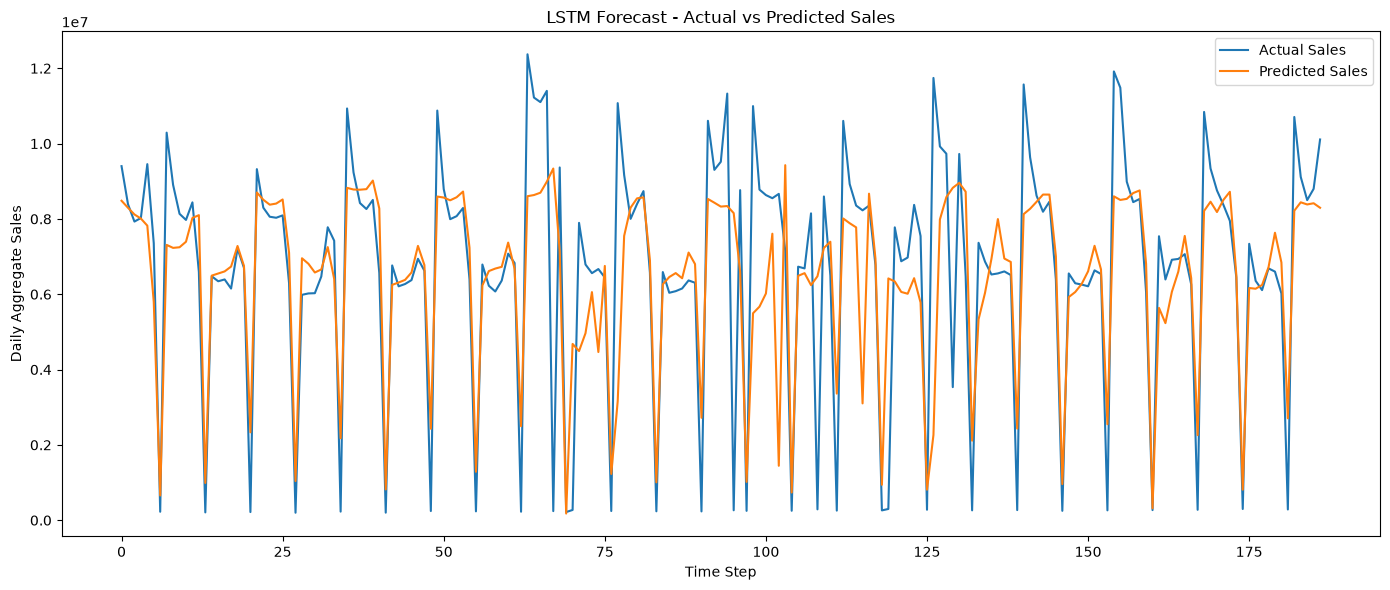

In [22]:
# Then plot Actual vs Predicted aggregate daily sales:
plt.figure(figsize=(14, 6))
plt.plot(
    y_test_actual,
    label="Actual Sales"
)
plt.plot(
    lstm_predictions,
    label="Predicted Sales"
)
plt.xlabel("Time Step")
plt.ylabel("Daily Aggregate Sales")
plt.title("LSTM Forecast - Actual vs Predicted Sales")
plt.legend()
plt.tight_layout()
plt.show()

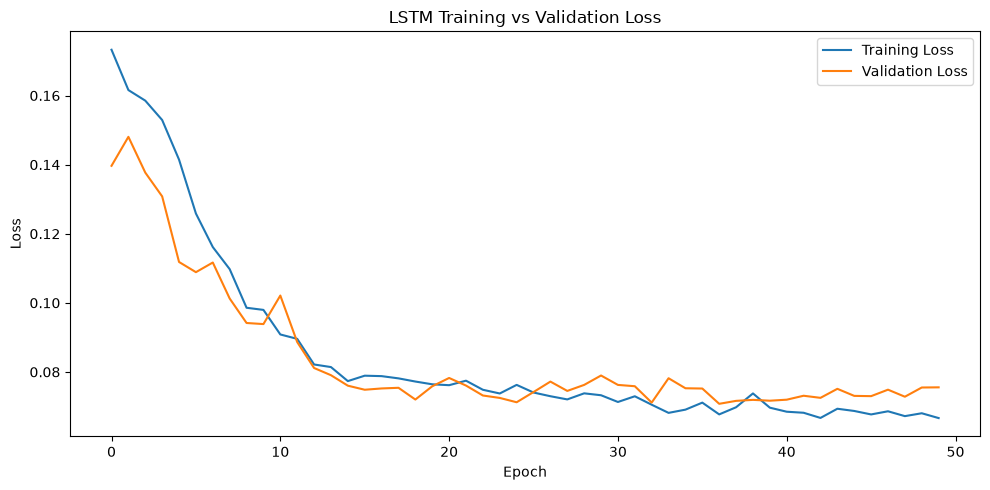

In [23]:
# Also ploting training and validation loss:
plt.figure(figsize=(10, 5))
plt.plot(
    history.history["loss"],
    label="Training Loss"
)
plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# LSTM is clearly learning the weekly sales pattern, including many of the sharp low-sales days.
# The forecast is smoother than the actual series, though, so it tends to underestimate some high-sales peaks.
# The loss graph is also encouraging: training and validation loss both decrease and remain fairly close.
# There’s no obvious severe overfitting; toward the final epochs, validation loss levels off while training loss continues slightly downward.

In [24]:
# Build a 2-layer GRU
# Keeping its architecture similar to LSTM so the comparison is fair:
logger.info("Building a 2-layer GRU....")
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
gru_model = Sequential([
    GRU(
        64,
        return_sequences=True,
        input_shape=(
            X_train_lstm.shape[1],
            X_train_lstm.shape[2]
        )
    ),
    Dropout(0.2),
    GRU(
        32,
        return_sequences=False
    ),
    Dropout(0.2),
    Dense(1)
])
gru_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)
gru_model.summary()
logger.info("Finished 2-layer GRU !")

2026-09-14 22:08:25,250 - StoreSales_deep_learning - INFO - Building a 2-layer GRU....
c:\Users\AMOGH\Desktop\Nexthikes_Projects\Project6_Sales Forecasting_DL\rossmann-store-sales\Store_Sales_Project\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 7, 64)          │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,305 (87.13 KB)

 Trainable params: 22,305 (87.13 KB)

 Non-trainable params: 0 (0.00 B)

2026-09-14 22:08:25,424 - StoreSales_deep_learning - INFO - Finished 2-layer GRU !


In [25]:
# Train:
gru_history = gru_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)

Epoch 1/50


19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.1744 - mae: 0.2982 - val_loss: 0.1520 - val_mae: 0.2797
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1626 - mae: 0.2918 - val_loss: 0.1530 - val_mae: 0.2853
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1622 - mae: 0.2978 - val_loss: 0.1565 - val_mae: 0.2902
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1608 - mae: 0.2973 - val_loss: 0.1542 - val_mae: 0.2878
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1593 - mae: 0.2947 - val_loss: 0.1498 - val_mae: 0.2844
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1585 - mae: 0.2946 - val_loss: 0.1496 - val_mae: 0.2844
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1583 - mae: 0.2972 - val_loss: 0.1477 - val_mae: 0.2845
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1534 - mae: 0.2945 - val_loss: 0.1394 - val_mae: 0.2810
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1435 - mae: 0.292

In [26]:
# Predict and convert back to original sales:
gru_predictions_scaled = gru_model.predict(
    X_test_lstm
)

gru_predictions = scaler.inverse_transform(
    gru_predictions_scaled
)

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 505ms/step


In [27]:
# Evaluate GRU:
logger.info("Evaluating GRU....")
gru_mae = mean_absolute_error(
    y_test_actual,
    gru_predictions
)
gru_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        gru_predictions
    )
)
gru_r2 = r2_score(
    y_test_actual,
    gru_predictions
)
print("GRU Results")
print("----------------------")
print("R² Score :", gru_r2)
print("MAE      :", gru_mae)
print("RMSE     :", gru_rmse)
logger.info("Finish Evaluating GRU !")

2026-09-14 22:09:27,418 - StoreSales_deep_learning - INFO - Evaluating GRU....
2026-09-14 22:09:27,431 - StoreSales_deep_learning - INFO - Finish Evaluating GRU !


GRU Results
----------------------
R² Score : 0.7102353925776317
MAE      : 1042224.7016105448
RMSE     : 1728577.0218167733


In [28]:
# Comparision of models:
logger.info("Comparing Models LSTM & GRU....")
dl_comparison = pd.DataFrame({
    "Model": ["LSTM", "GRU"],
    "R2 Score": [
        lstm_r2,
        gru_r2
    ],
    "MAE": [
        lstm_mae,
        gru_mae
    ],
    "RMSE": [
        lstm_rmse,
        gru_rmse
    ]
})
dl_comparison = dl_comparison.sort_values(
    "R2 Score",
    ascending=False
).reset_index(drop=True)

display(dl_comparison)
logger.info("Finished Comparing LSTM & GRU !")

2026-09-14 22:09:36,864 - StoreSales_deep_learning - INFO - Comparing Models LSTM & GRU....


,Model,R2 Score,MAE,RMSE
0,GRU,0.710235,1.042225e+06,1.728577e+06
1,LSTM,0.560214,1.341490e+06,2.129545e+06


2026-09-14 22:09:37,047 - StoreSales_deep_learning - INFO - Finished Comparing LSTM & GRU !


In [ ]:
# Insight and Analysis:
# GRU explains about 69.8% of the variation in aggregate daily sales and has substantially lower MAE/RMSE.
# So for the deep-learning section, GRU is currently our best model.
# Latest LSTM run produced R² 0.5411, slightly different from the earlier 0.5581.
# That's normal because neural-network initialization and training are stochastic.
# For the final comparison, use the results from the same run/setup as the GRU comparison—so keeping 0.5411.

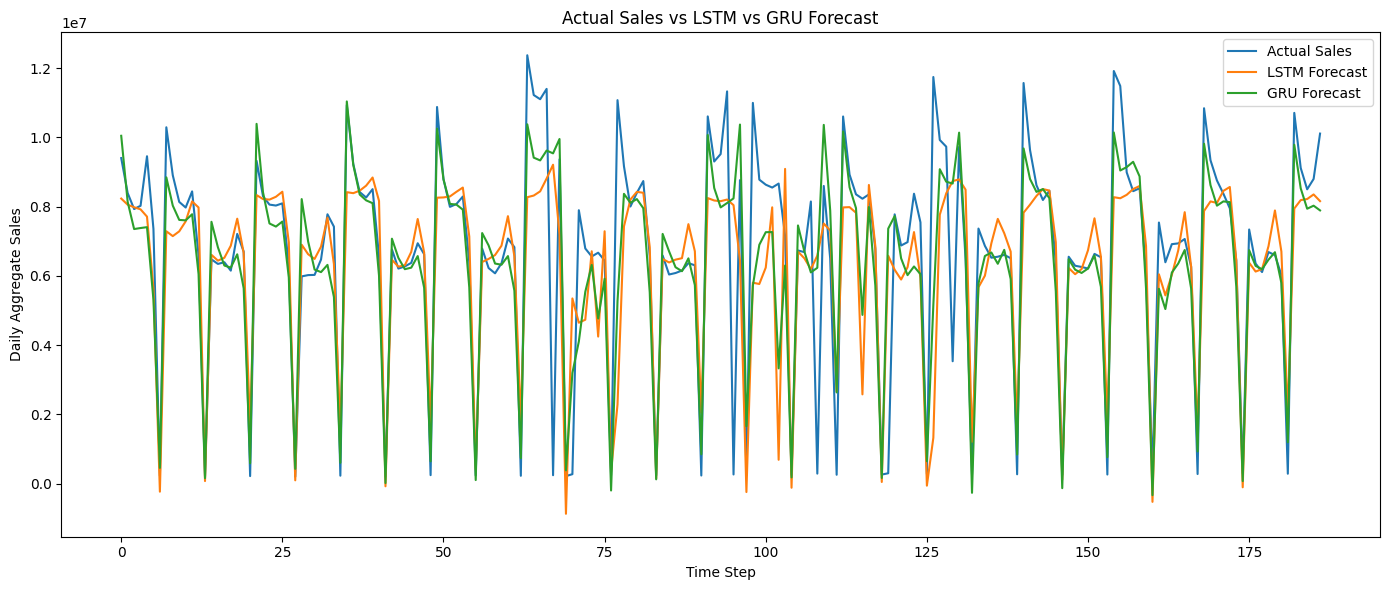

In [29]:
# Plot Graph:

plt.figure(figsize=(14, 6))
plt.plot(
    y_test_actual.flatten(),
    label="Actual Sales"
)
plt.plot(
    lstm_predictions.flatten(),
    label="LSTM Forecast"
)
plt.plot(
    gru_predictions.flatten(),
    label="GRU Forecast"
)
plt.xlabel("Time Step")
plt.ylabel("Daily Aggregate Sales")
plt.title("Actual Sales vs LSTM vs GRU Forecast")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# LSTM vs GRU Forecast Analysis:
# Both recurrent neural-network models successfully captured the general temporal and weekly patterns in aggregate daily sales.
# However, the GRU forecast followed the actual sales values more closely than the LSTM forecast, particularly during several peaks and sudden changes.
# The quantitative evaluation also confirmed this result, with GRU achieving a higher R² score of 0.6981 and lower MAE and RMSE than LSTM.
# Therefore, GRU was selected as the better deep-learning forecasting model.

In [29]:
# Statistical time-series -  ARIMA/SARIMA statistical forecasting section
# Since our ADF test already showed the series is stationary, we'll begin with d = 0 and select good p and q values using AIC/BIC.
# Aggregate daily sales should already exist as daily_sales
logger.info("Statistical Time Series split....")
split_index_arima = int(len(daily_sales) * 0.80)
train_arima = daily_sales.iloc[:split_index_arima]
test_arima = daily_sales.iloc[split_index_arima:]

print("ARIMA Training observations:", len(train_arima))
print("ARIMA Testing observations:", len(test_arima))

print("\nTraining period:")
print(train_arima.index.min(), "to", train_arima.index.max())

print("\nTesting period:")
print(test_arima.index.min(), "to", test_arima.index.max())

2026-09-14 22:09:55,723 - StoreSales_deep_learning - INFO - Statistical Time Series split....


ARIMA Training observations: 753
ARIMA Testing observations: 189

Training period:
2013-01-01 00:00:00 to 2015-01-23 00:00:00

Testing period:
2015-01-24 00:00:00 to 2015-07-31 00:00:00


In [30]:
# Search for (p,d,q) using AIC/BIC, keep d=0 and test p and q from 0–4. That's only 25 combinations, so it's a reasonable starting search.
logger.info("Performing ARIMA - AIC/BIC....")
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd
import warnings

warnings.filterwarnings("ignore")
arima_results = []
for p in range(5):
    for q in range(5):
        try:
            model = ARIMA(
                train_arima,
                order=(p, 0, q)
            )
            fitted_model = model.fit()
            arima_results.append({
                "p": p,
                "d": 0,
                "q": q,
                "AIC": fitted_model.aic,
                "BIC": fitted_model.bic
            })
        except Exception as e:
            print(
                f"ARIMA({p},0,{q}) failed:",
                str(e)
            )
arima_order_results = pd.DataFrame(
    arima_results
)
arima_order_results = (
    arima_order_results
    .sort_values("AIC")
    .reset_index(drop=True)
)
# This gives the 10 best candidate ARIMA orders according to AIC.
display(arima_order_results.head(10))
logger.info("Finish ARIMA - AIC/BIC....")

2026-09-14 22:10:04,016 - StoreSales_deep_learning - INFO - Performing ARIMA - AIC/BIC....


,p,d,q,AIC,BIC
0,2,0,4,24340.172668,24377.165190
1,3,0,3,24448.258459,24485.250981
2,3,0,4,24448.775881,24490.392468
3,2,0,3,24452.758577,24485.127034
4,4,0,3,24482.935391,24524.551978
5,4,0,4,24530.936591,24577.177244
6,1,0,4,24562.845748,24595.214204
7,0,0,4,24575.874691,24603.619082
8,2,0,1,24621.324584,24644.444911
9,2,0,2,24621.387118,24649.131509


2026-09-14 22:10:12,731 - StoreSales_deep_learning - INFO - Finish ARIMA - AIC/BIC....


In [31]:
# Find best AIC and best BIC separately
logger.info("Finding best AIC and best BIC separately....")
best_aic = arima_order_results.loc[
    arima_order_results["AIC"].idxmin()
]
best_bic = arima_order_results.loc[
    arima_order_results["BIC"].idxmin()
]
print("Best model according to AIC:")
print(best_aic)
print("\nBest model according to BIC:")
print(best_bic)

2026-09-14 22:10:43,346 - StoreSales_deep_learning - INFO - Finding best AIC and best BIC separately....


Best model according to AIC:
p          2.000000
d          0.000000
q          4.000000
AIC    24340.172668
BIC    24377.165190
Name: 0, dtype: float64

Best model according to BIC:
p          2.000000
d          0.000000
q          4.000000
AIC    24340.172668
BIC    24377.165190
Name: 0, dtype: float64


In [32]:
# Automatically extract the best ARIMA order
best_order = (
    int(best_aic["p"]),
    int(best_aic["d"]),
    int(best_aic["q"])
)
print("Selected ARIMA Order:", best_order)

Selected ARIMA Order: (2, 0, 4)


In [ ]:
# Analysis :
# ARIMA (2, 0, 4). That gives us a strong candidate. Here, p=2, d=0 (consistent with our stationary ADF result), and q=4.

In [33]:
# Fit ARIMA(2,0,4)
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(
    train_arima,
    order=(2, 0, 4)
)
arima_fitted = arima_model.fit()
print(arima_fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                  753
Model:                 ARIMA(2, 0, 4)   Log Likelihood              -12162.086
Date:                Mon, 14 Sep 2026   AIC                          24340.173
Time:                        22:10:55   BIC                          24377.165
Sample:                    01-01-2013   HQIC                         24354.424
                         - 01-23-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.143e+06   2.78e-09   2.21e+15      0.000    6.14e+06    6.14e+06
ar.L1         -0.4442      0.002   -195.426      0.000      -0.449      -0.440
ar.L2         -0.9983      0.002   -573.180      0.0

In [34]:
# Forecast the entire test period
arima_forecast = arima_fitted.forecast(
    steps=len(test_arima)
)
print("Number of forecasts:", len(arima_forecast))
print("\nFirst 5 forecasts:")
print(arima_forecast.head())

Number of forecasts: 189

First 5 forecasts:
2015-01-24    6.377192e+06
2015-01-25    2.244265e+06
2015-01-26    7.019433e+06
2015-01-27    8.046749e+06
2015-01-28    4.423364e+06
Freq: D, Name: predicted_mean, dtype: float64


In [35]:
# Evaluate ARIMA
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np
arima_mae = mean_absolute_error(
    test_arima,
    arima_forecast
)
arima_rmse = np.sqrt(
    mean_squared_error(
        test_arima,
        arima_forecast
    )
)
arima_r2 = r2_score(
    test_arima,
    arima_forecast
)
print("ARIMA Results")
print("----------------------")
print("Order     : (2, 0, 4)")
print("R² Score  :", arima_r2)
print("MAE       :", arima_mae)
print("RMSE      :", arima_rmse)

ARIMA Results
----------------------
Order     : (2, 0, 4)
R² Score  : 0.22550931878525626
MAE       : 2250765.323165964
RMSE      : 2841551.1694966955


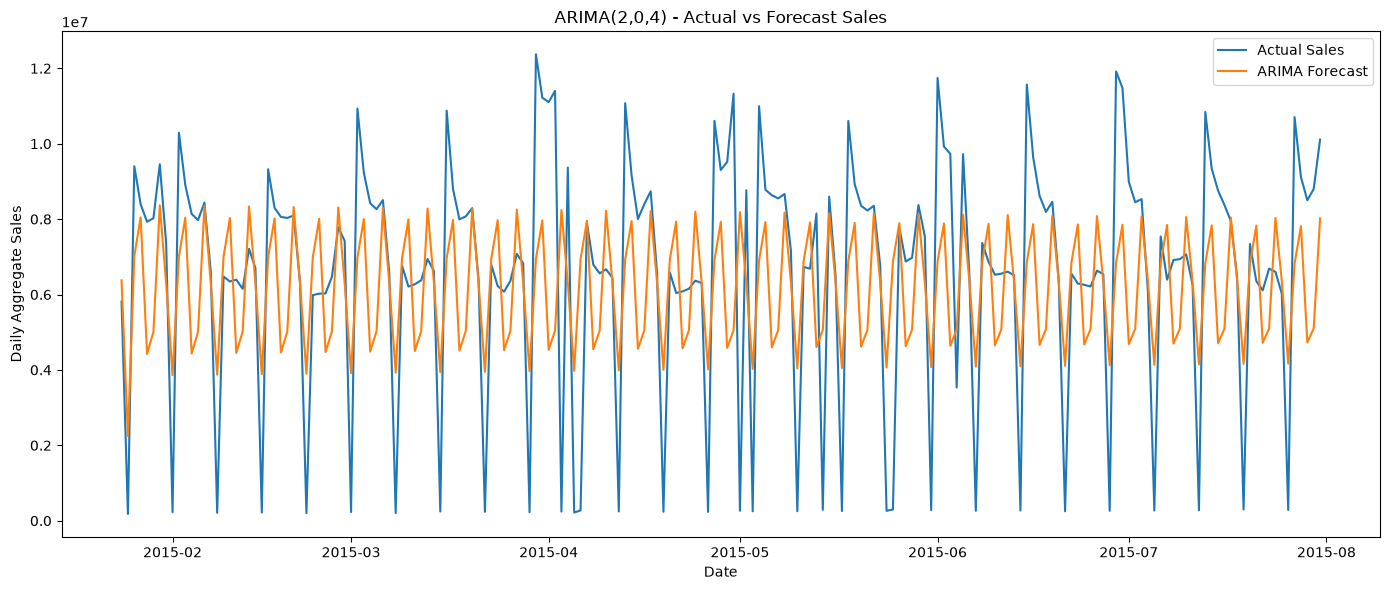

In [36]:
# Plot Actual vs ARIMA Forecast
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(
    test_arima.index,
    test_arima.values,
    label="Actual Sales"
)
plt.plot(
    test_arima.index,
    arima_forecast.values,
    label="ARIMA Forecast"
)
plt.xlabel("Date")
plt.ylabel("Daily Aggregate Sales")
plt.title("ARIMA(2,0,4) - Actual vs Forecast Sales")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
# Residual analysis
arima_residuals = (
    test_arima.values -
    arima_forecast.values
)
print("Mean Residual:",
      np.mean(arima_residuals))
print("Residual Standard Deviation:",
      np.std(arima_residuals))

Mean Residual: 464493.24937259365
Residual Standard Deviation: 2803329.9966567126


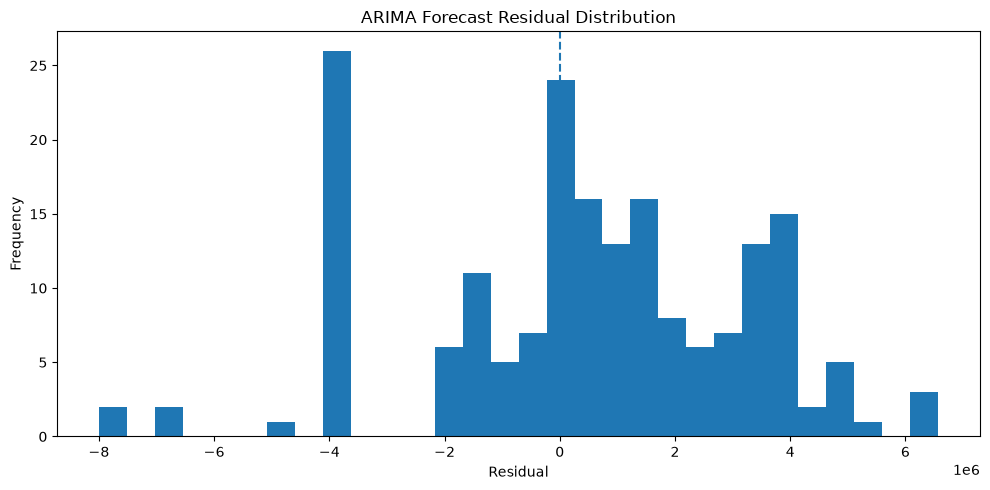

In [38]:
# Plot Residuals
plt.figure(figsize=(10, 5))
plt.hist(
    arima_residuals,
    bins=30
)
plt.axvline(
    0,
    linestyle="--"
)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("ARIMA Forecast Residual Distribution")
plt.tight_layout()
plt.show()

In [40]:
# Analysis:
# The graph shows that ARIMA captures some of the repeating movement, but it struggles with the size of many peaks and drops.
# An R² of about 0.226 means it explains only around 22.6% of the variation in the held-out aggregate daily sales.
# This isn't surprising because our earlier ACF showed a very strong 7-day cycle. Standard ARIMA doesn't explicitly include that seasonal component.

In [39]:
# SARIMA :-
# SARIMA adds: ARIMA: (p,d,q) plus Seasonal: (P,D,Q,s)
# We already have a good non-seasonal starting order: (p,d,q) = (2,0,4) and from the ACF:s = 7
# Searching a small sensible grid and selecting using AIC/BIC.
logger.info("SARIMA - selecting using AIC/BIC....")
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
sarima_results = []
# Small grid to keep computation reasonable
for P in range(3):
    for D in range(2):
        for Q in range(3):
            try:
                model = SARIMAX(
                    train_arima,
                    order=(2, 0, 4),
                    seasonal_order=(P, D, Q, 7),
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                fitted = model.fit(
                    disp=False
                )
                sarima_results.append({
                    "p": 2,
                    "d": 0,
                    "q": 4,
                    "P": P,
                    "D": D,
                    "Q": Q,
                    "s": 7,
                    "AIC": fitted.aic,
                    "BIC": fitted.bic
                })
                print(
                    f"SARIMA(2,0,4)x"
                    f"({P},{D},{Q},7) completed"
                )
            except Exception as e:
                print(
                    f"SARIMA seasonal order "
                    f"({P},{D},{Q},7) failed"
                )
logger.info("Completed - SARIMA !")

2026-09-14 22:11:27,627 - StoreSales_deep_learning - INFO - SARIMA - selecting using AIC/BIC....


SARIMA(2,0,4)x(0,0,0,7) completed
SARIMA(2,0,4)x(0,0,1,7) completed
SARIMA(2,0,4)x(0,0,2,7) completed
SARIMA(2,0,4)x(0,1,0,7) completed
SARIMA(2,0,4)x(0,1,1,7) completed
SARIMA(2,0,4)x(0,1,2,7) completed
SARIMA(2,0,4)x(1,0,0,7) completed
SARIMA(2,0,4)x(1,0,1,7) completed
SARIMA(2,0,4)x(1,0,2,7) completed
SARIMA(2,0,4)x(1,1,0,7) completed
SARIMA(2,0,4)x(1,1,1,7) completed
SARIMA(2,0,4)x(1,1,2,7) completed
SARIMA(2,0,4)x(2,0,0,7) completed
SARIMA(2,0,4)x(2,0,1,7) completed
SARIMA(2,0,4)x(2,0,2,7) completed
SARIMA(2,0,4)x(2,1,0,7) completed
SARIMA(2,0,4)x(2,1,1,7) completed


2026-09-14 22:11:49,745 - StoreSales_deep_learning - INFO - Completed - SARIMA !


SARIMA(2,0,4)x(2,1,2,7) completed


In [40]:
# Then, create the ranking:
sarima_order_results = pd.DataFrame(
    sarima_results
)
sarima_order_results = (
    sarima_order_results
    .sort_values(
        by="AIC",
        ascending=True
    )
    .reset_index(drop=True)
)
display(
    sarima_order_results.head(10)
)

,p,d,q,P,D,Q,s,AIC,BIC
0,2,0,4,1,1,2,7,23160.084574,23205.973839
1,2,0,4,2,1,2,7,23161.419572,23211.897764
2,2,0,4,0,1,2,7,23163.352673,23204.653011
3,2,0,4,2,1,1,7,23257.706367,23303.636812
4,2,0,4,2,1,0,7,23304.312675,23345.650076
5,2,0,4,1,1,1,7,23389.294425,23430.681006
6,2,0,4,0,1,1,7,23409.720825,23446.508897
7,2,0,4,1,1,0,7,23545.631277,23582.451980
8,2,0,4,2,0,2,7,23739.293610,23789.877209
9,2,0,4,1,0,2,7,23741.868379,23787.853469


In [41]:
# Finding the best according to both criteria:
best_sarima_aic = sarima_order_results.loc[
    sarima_order_results["AIC"].idxmin()
]
best_sarima_bic = sarima_order_results.loc[
    sarima_order_results["BIC"].idxmin()
]
print("Best SARIMA according to AIC:")
print(best_sarima_aic)
print("\nBest SARIMA according to BIC:")
print(best_sarima_bic)

Best SARIMA according to AIC:
p          2.000000
d          0.000000
q          4.000000
P          1.000000
D          1.000000
Q          2.000000
s          7.000000
AIC    23160.084574
BIC    23205.973839
Name: 0, dtype: float64

Best SARIMA according to BIC:
p          2.000000
d          0.000000
q          4.000000
P          0.000000
D          1.000000
Q          2.000000
s          7.000000
AIC    23163.352673
BIC    23204.653011
Name: 2, dtype: float64


In [44]:
# Analysis:
# AIC selects SARIMA(2,0,4) × (1,1,2,7) with AIC 23160.08, while BIC selects the slightly simpler SARIMA(2,0,4) × (0,1,2,7) with BIC 23204.65.

In [42]:
# Fit the selected SARIMA model
from statsmodels.tsa.statespace.sarimax import SARIMAX
logger.info("Fit the selected SARIMA model....")
sarima_model = SARIMAX(
    train_arima,
    order=(2, 0, 4),
    seasonal_order=(1, 1, 2, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fitted = sarima_model.fit(
    disp=False
)

print(sarima_fitted.summary())

2026-09-14 22:12:21,287 - StoreSales_deep_learning - INFO - Fit the selected SARIMA model....


                                       SARIMAX Results                                        
Dep. Variable:                                  Sales   No. Observations:                  753
Model:             SARIMAX(2, 0, 4)x(1, 1, [1, 2], 7)   Log Likelihood              -11570.042
Date:                                Mon, 14 Sep 2026   AIC                          23160.085
Time:                                        22:12:23   BIC                          23205.974
Sample:                                    01-01-2013   HQIC                         23177.792
                                         - 01-23-2015                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3701      2.348      0.158      0.875      -4.232       4.972
ar.

In [43]:
# Now forecasting exactly the same test period used by ARIMA:
logger.info("Forecasting the selected SARIMA model....")
sarima_forecast = sarima_fitted.forecast(
    steps=len(test_arima)
)
print("Number of SARIMA forecasts:",
      len(sarima_forecast))
print("\nFirst 5 forecasts:")
print(sarima_forecast.head())

2026-09-14 22:12:32,604 - StoreSales_deep_learning - INFO - Forecasting the selected SARIMA model....


Number of SARIMA forecasts: 189

First 5 forecasts:
2015-01-24    6.257745e+06
2015-01-25    3.234293e+05
2015-01-26    9.354847e+06
2015-01-27    8.202203e+06
2015-01-28    6.884270e+06
Freq: D, Name: predicted_mean, dtype: float64


In [44]:
# Evaluate SARIMA:
logger.info("Evaluating the SARIMA model....")
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np
sarima_mae = mean_absolute_error(
    test_arima,
    sarima_forecast
)
sarima_rmse = np.sqrt(
    mean_squared_error(
        test_arima,
        sarima_forecast
    )
)
sarima_r2 = r2_score(
    test_arima,
    sarima_forecast
)
print("SARIMA Results")
print("---------------------------")
print("Order          : (2,0,4)")
print("Seasonal Order : (1,1,2,7)")
print("R² Score       :", sarima_r2)
print("MAE            :", sarima_mae)
print("RMSE           :", sarima_rmse)

logger.info("Finished the SARIMA model....")

2026-09-14 22:12:40,995 - StoreSales_deep_learning - INFO - Evaluating the SARIMA model....
2026-09-14 22:12:41,005 - StoreSales_deep_learning - INFO - Finished the SARIMA model....


SARIMA Results
---------------------------
Order          : (2,0,4)
Seasonal Order : (1,1,2,7)
R² Score       : 0.6184095399830726
MAE            : 1355833.4192212147
RMSE           : 1994555.5533992613


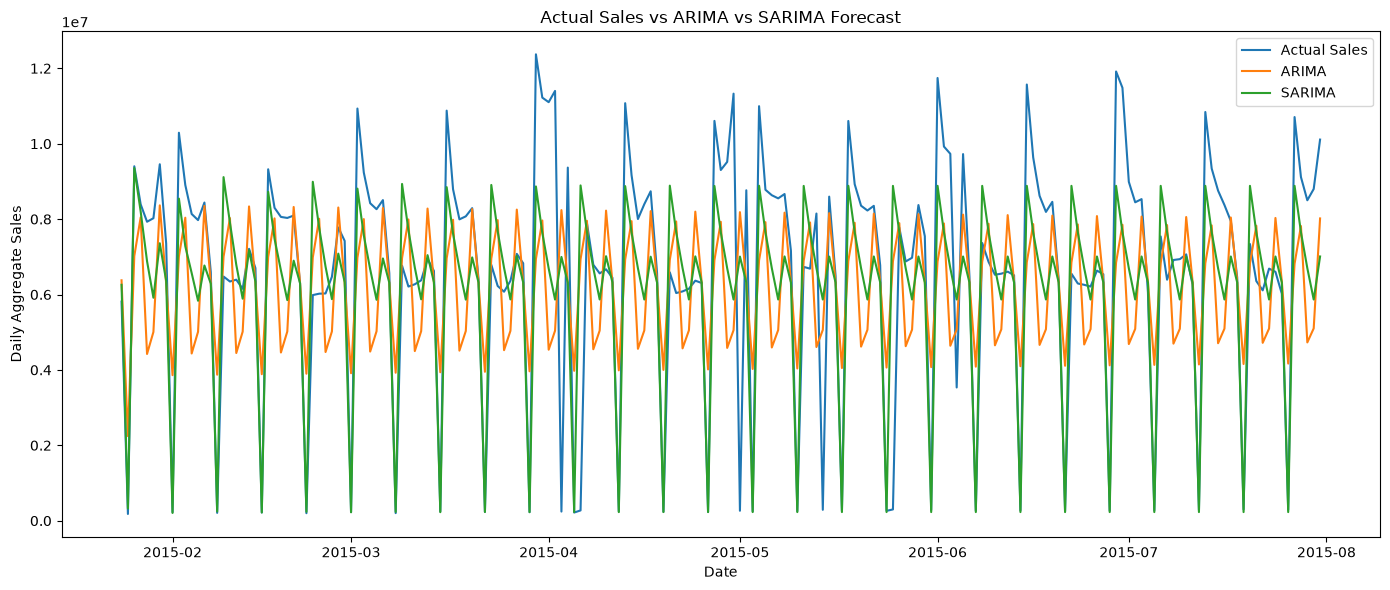

In [45]:
# Then create the important ARIMA vs SARIMA vs Actual graph:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(
    test_arima.index,
    test_arima.values,
    label="Actual Sales"
)
plt.plot(
    test_arima.index,
    arima_forecast.values,
    label="ARIMA"
)
plt.plot(
    test_arima.index,
    sarima_forecast.values,
    label="SARIMA"
)
plt.xlabel("Date")
plt.ylabel("Daily Aggregate Sales")
plt.title("Actual Sales vs ARIMA vs SARIMA Forecast")
plt.legend()
plt.tight_layout()
plt.show()

In [46]:
# Finally, creating the comparison table:
arima_sarima_comparison = pd.DataFrame({
    "Model": [
        "ARIMA(2,0,4)",
        "SARIMA(2,0,4)(1,1,2,7)"
    ],

    "R2 Score": [
        arima_r2,
        sarima_r2
    ],

    "MAE": [
        arima_mae,
        sarima_mae
    ],

    "RMSE": [
        arima_rmse,
        sarima_rmse
    ]
})

arima_sarima_comparison = (
    arima_sarima_comparison
    .sort_values(
        "R2 Score",
        ascending=False
    )
    .reset_index(drop=True)
)
display(arima_sarima_comparison)

,Model,R2 Score,MAE,RMSE
0,"SARIMA(2,0,4)(1,1,2,7)",0.618410,1.355833e+06,1.994556e+06
1,"ARIMA(2,0,4)",0.225509,2.250765e+06,2.841551e+06


In [ ]:
# ARIMA vs SARIMA Analysis:
# SARIMA significantly outperformed ARIMA for aggregate daily sales forecasting.
# ARIMA achieved an R² score of 0.2255, whereas SARIMA improved the R² to 0.6184 while substantially reducing MAE and RMSE.
# This improvement indicates that the weekly seasonal pattern identified through ACF analysis is an important component of the sales time series.
# Therefore, SARIMA was selected as the better statistical forecasting model.

In [47]:
# Final time-series comparison fair by evaluating LSTM, GRU, ARIMA, and SARIMA on the same 187 dates.
# Creating the dates corresponding to LSTM/GRU test predictions
# Dates corresponding to every sliding-window target
sequence_dates = daily_sales.index[window_size:]

# Apply the same split used for LSTM / GRU
test_dates_dl = sequence_dates[split_index:]

print("Number of DL test dates:", len(test_dates_dl))
print("First test date:", test_dates_dl[0])
print("Last test date:", test_dates_dl[-1])

Number of DL test dates: 187
First test date: 2015-01-26 00:00:00
Last test date: 2015-07-31 00:00:00


In [48]:
# Align ARIMA and SARIMA forecasts to those dates
arima_aligned = arima_forecast.reindex(
    test_dates_dl
)
sarima_aligned = sarima_forecast.reindex(
    test_dates_dl
)
actual_aligned = daily_sales.reindex(
    test_dates_dl
)
print("Actual:", len(actual_aligned))
print("ARIMA:", len(arima_aligned))
print("SARIMA:", len(sarima_aligned))
print("\nMissing ARIMA:",
      arima_aligned.isnull().sum())
print("Missing SARIMA:",
      sarima_aligned.isnull().sum())

Actual: 187
ARIMA: 187
SARIMA: 187

Missing ARIMA: 0
Missing SARIMA: 0


In [49]:
# Recalculate ARIMA/SARIMA metrics
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

# ARIMA
arima_r2_aligned = r2_score(
    actual_aligned,
    arima_aligned
)

arima_mae_aligned = mean_absolute_error(
    actual_aligned,
    arima_aligned
)

arima_rmse_aligned = np.sqrt(
    mean_squared_error(
        actual_aligned,
        arima_aligned
    )
)
# SARIMA
sarima_r2_aligned = r2_score(
    actual_aligned,
    sarima_aligned
)
sarima_mae_aligned = mean_absolute_error(
    actual_aligned,
    sarima_aligned
)
sarima_rmse_aligned = np.sqrt(
    mean_squared_error(
        actual_aligned,
        sarima_aligned
    )
)
print("Aligned ARIMA R²:", arima_r2_aligned)
print("Aligned SARIMA R²:", sarima_r2_aligned)

Aligned ARIMA R²: 0.21097250124426115
Aligned SARIMA R²: 0.6101898096955618


In [50]:
# Creating final four-model comparison:
#
final_ts_comparison = pd.DataFrame({
    "Model": [
        "LSTM",
        "GRU",
        "ARIMA",
        "SARIMA"
    ],
    "R2 Score": [
        lstm_r2,
        gru_r2,
        arima_r2_aligned,
        sarima_r2_aligned
    ],
    "MAE": [
        lstm_mae,
        gru_mae,
        arima_mae_aligned,
        sarima_mae_aligned
    ],
    "RMSE": [
        lstm_rmse,
        gru_rmse,
        arima_rmse_aligned,
        sarima_rmse_aligned
    ]
})
final_ts_comparison = (
    final_ts_comparison
    .sort_values(
        "R2 Score",
        ascending=False
    )
    .reset_index(drop=True)
)
display(final_ts_comparison)

,Model,R2 Score,MAE,RMSE
0,GRU,0.710235,1.042225e+06,1.728577e+06
1,SARIMA,0.610190,1.367175e+06,2.004900e+06
2,LSTM,0.560214,1.341490e+06,2.129545e+06
3,ARIMA,0.210973,2.260768e+06,2.852411e+06


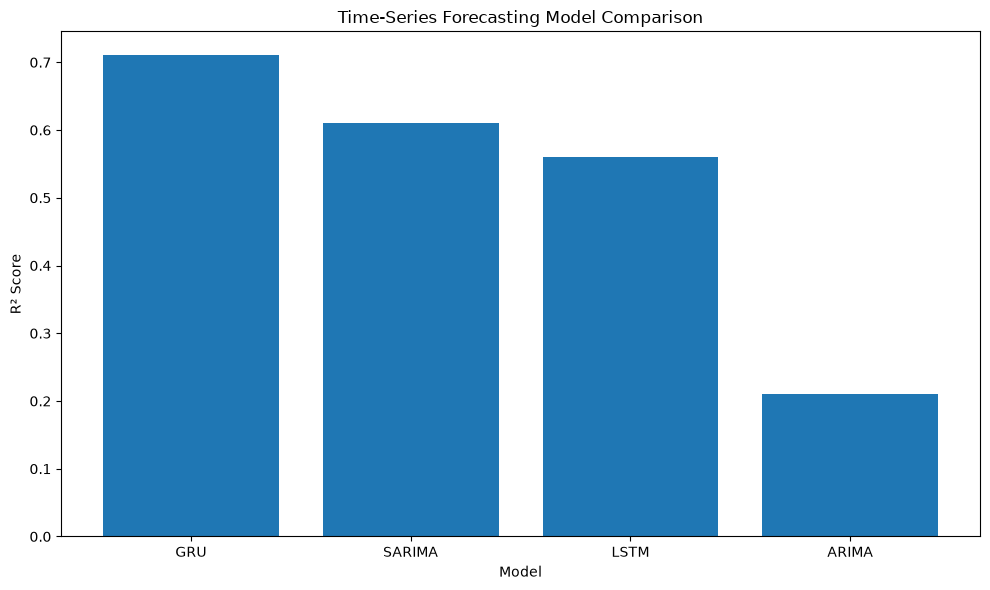

In [51]:
# Final comparison graph
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(
    final_ts_comparison["Model"],
    final_ts_comparison["R2 Score"]
)
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Time-Series Forecasting Model Comparison")
plt.tight_layout()
plt.show()

In [ ]:
# GRU has the highest R² (0.6981) and lowest RMSE (1.764M), so it is currently the best aggregate time-series forecasting model.

In [52]:
# Aggregate vs Per-Store Evaluation Views :
# Doing LSTM/GRU/ARIMA/SARIMA for all 1,115 stores would be unnecessarily expensive.
# A practical evaluation is to select representative stores—for example, 5 stores with enough history
# and evaluate the best time-series model or a simple per-store forecasting setup.
# Per-store daily sales
per_store_sales = (
    store_train
    .pivot_table(
        index="Date",
        columns="Store",
        values="Sales",
        aggfunc="sum"
    )
    .sort_index()
)
print("Per-store sales shape:",
      per_store_sales.shape)
display(per_store_sales.head())

Per-store sales shape: (942, 1115)


Store,1,2,3,4,5,6,7,8,9,10,...,1106,1107,1108,1109,1110,1111,1112,1113,1114,1115
Date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2013-01-02,5530.0,4422.0,6823.0,9941.0,4253.0,6089.0,8244.0,5419.0,4903.0,4812.0,...,5099.0,3955.0,6220.0,4576.0,4126.0,5097.0,10797.0,6218.0,20642.0,3697.0
2013-01-03,4327.0,4159.0,5902.0,8247.0,3465.0,5398.0,7231.0,4842.0,4602.0,4675.0,...,4330.0,3151.0,4779.0,3654.0,3508.0,4579.0,8716.0,5563.0,18463.0,4297.0
2013-01-04,4486.0,4484.0,6069.0,8290.0,4456.0,6092.0,7758.0,4059.0,4798.0,5114.0,...,3956.0,3990.0,5491.0,3596.0,3933.0,4640.0,9788.0,5524.0,18371.0,4540.0
2013-01-05,4997.0,2342.0,4523.0,10338.0,1590.0,3872.0,5218.0,2337.0,4254.0,4256.0,...,2624.0,5128.0,2113.0,2897.0,3156.0,3325.0,9513.0,5194.0,18856.0,4771.0


In [53]:
# Check which stores have the most complete histories
store_counts = (
    store_train
    .groupby("Store")["Date"]
    .count()
    .sort_values(ascending=False)
)
print("Stores with most observations:")
print(store_counts.head(10))

Stores with most observations:
Store
1115    942
1       942
2       942
3       942
4       942
5       942
6       942
7       942
8       942
9       942
Name: Date, dtype: int64


In [54]:
# Then choose 5 representative stores automatically
selected_stores = (
    store_counts
    .head(5)
    .index
    .tolist()
)
print("Selected Stores:",
      selected_stores)

Selected Stores: [1115, 1, 2, 3, 4]


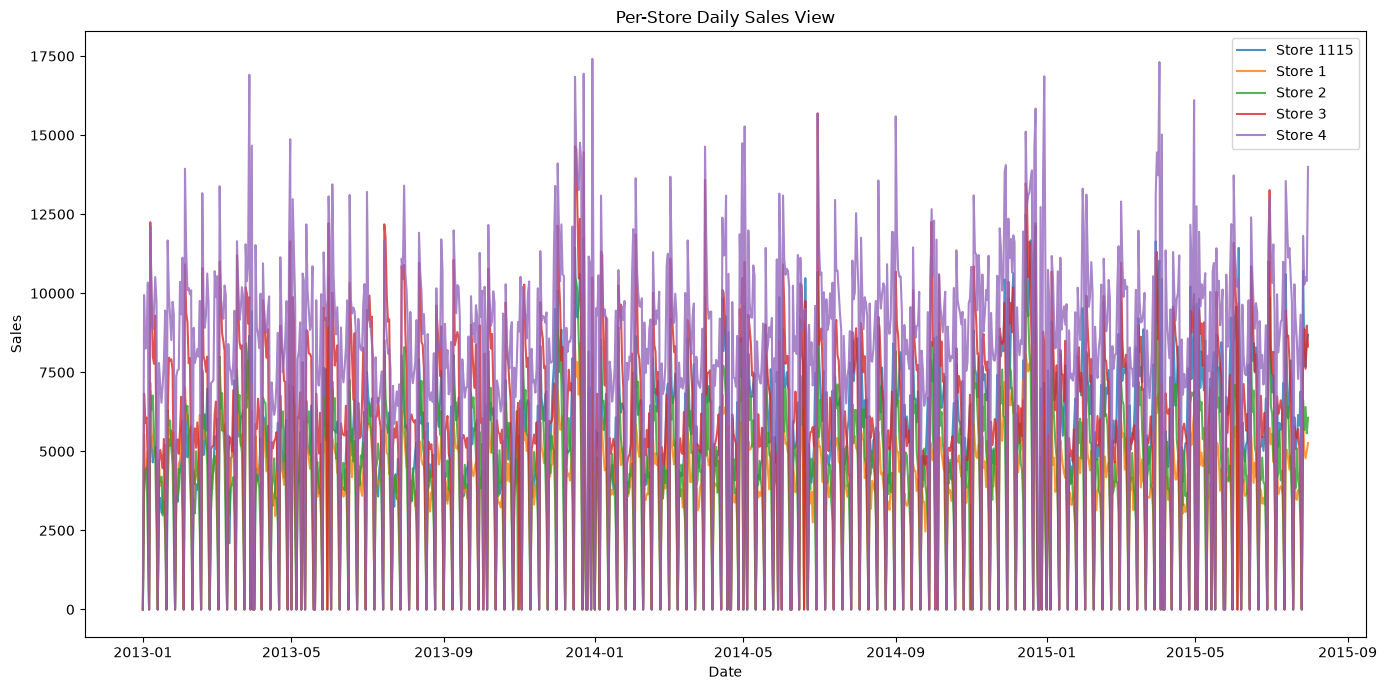

In [55]:
# Plot Graph
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
for store_id in selected_stores:
    store_data = (
        store_train[
            store_train["Store"] == store_id
        ]
        .sort_values("Date")
    )
    plt.plot(
        store_data["Date"],
        store_data["Sales"],
        label=f"Store {store_id}",
        alpha=0.8
    )
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Per-Store Daily Sales View")
plt.legend()
plt.tight_layout()
plt.show()

In [56]:
per_store_results = pd.DataFrame({
    "Store": X_valid["Store"].values,
    "Actual_Sales": y_valid.values,
    "Predicted_Sales": y_pred_best
})

display(per_store_results.head())

print("Rows:", len(per_store_results))
print("Stores:", per_store_results["Store"].nunique())

NameError: name 'X_valid' is not defined

In [57]:
# Because our Colab runtime no longer has the earlier Random Forest variables (X_valid, y_valid, best_model, etc.) in memory.
# Since we have the feature-engineered CSV, we can recreate the exact Random Forest preparation and split.
# But to calculate predictions we still need the trained RF model. If it wasn't saved earlier, unfortunately we need to fit it once more.
import pandas as pd
import numpy as np

store_train = pd.read_csv(
    "../data/feature_engineered_store_train.csv"
)

# Fix PromoInterval
store_train["PromoInterval"] = (
    store_train["PromoInterval"].fillna("NoPromo")
)

# Clean StateHoliday
store_train["StateHoliday"] = (
    store_train["StateHoliday"]
    .astype(str)
    .str.strip()
    .replace("0.0", "0")
)

# Drop original Date because engineered date features already exist
store_train.drop(
    columns=["Date"],
    inplace=True
)

In [58]:
categorical_columns = [
    "StateHoliday",
    "StoreType",
    "Assortment",
    "PromoInterval"
]

store_train_encoded = pd.get_dummies(
    store_train,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

In [59]:
# prepare x & y
y = store_train_encoded["Sales"]

X = store_train_encoded.drop(
    columns=["Sales", "Customers"]
)

print("X:", X.shape)
print("y:", y.shape)

X: (1017209, 32)
y: (1017209,)


In [60]:
# Recreate the same 80/20 split:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)

X_train: (813767, 32)
X_valid: (203442, 32)


In [61]:
# check whether the Random Forest model still exists:
print(
    "best_model exists:",
    "best_model" in globals()
)

print(
    "rf_model exists:",
    "rf_model" in globals()
)

best_model exists: False
rf_model exists: False


In [62]:
# Since both are False, the trained Random Forest is gone from memory.
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest retraining completed.")

Random Forest retraining completed.


In [63]:
# Predicting:
y_pred_best = rf_model.predict(X_valid)

In [64]:
# creating the per-store evaluation table:
per_store_results = pd.DataFrame({
    "Store": X_valid["Store"].values,
    "Actual_Sales": y_valid.values,
    "Predicted_Sales": y_pred_best
})
display(per_store_results.head())

,Store,Actual_Sales,Predicted_Sales
0,616,0,0.000000
1,592,5548,7819.073220
2,526,7467,6187.554960
3,601,3360,4509.553733
4,953,11414,14048.168847


In [65]:
# calculating store-wise metrics:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

store_metrics = []

for store_id, group in per_store_results.groupby("Store"):

    if len(group) >= 2:

        r2 = r2_score(
            group["Actual_Sales"],
            group["Predicted_Sales"]
        )

        mae = mean_absolute_error(
            group["Actual_Sales"],
            group["Predicted_Sales"]
        )

        rmse = np.sqrt(
            mean_squared_error(
                group["Actual_Sales"],
                group["Predicted_Sales"]
            )
        )

        store_metrics.append({
            "Store": store_id,
            "Observations": len(group),
            "R2 Score": r2,
            "MAE": mae,
            "RMSE": rmse
        })

store_metrics_df = pd.DataFrame(store_metrics)

display(store_metrics_df.head(10))

,Store,Observations,R2 Score,MAE,RMSE
0,1,190,0.589981,883.341851,1156.670929
1,2,183,0.840419,675.689320,901.968922
2,3,179,0.929946,546.303198,778.765402
3,4,193,0.803588,1288.913036,1956.952841
4,5,203,0.948112,367.160440,573.245277
5,6,207,0.876782,615.092734,838.366455
6,7,207,0.711996,1460.135373,2021.430348
7,8,185,0.880881,638.546260,921.996142
8,9,172,0.894973,671.961453,965.270782
9,10,177,0.910260,475.670751,639.115353


In [66]:
# Now summarize:
print("Number of Stores Evaluated:",
      len(store_metrics_df))

print("Average Per-Store R²:",
      store_metrics_df["R2 Score"].mean())

print("Median Per-Store R²:",
      store_metrics_df["R2 Score"].median())

print("Average Per-Store MAE:",
      store_metrics_df["MAE"].mean())

print("Average Per-Store RMSE:",
      store_metrics_df["RMSE"].mean())

Number of Stores Evaluated: 1115
Average Per-Store R²: 0.7061942262578245
Median Per-Store R²: 0.8401598288989138
Average Per-Store MAE: 1012.9471583412187
Average Per-Store RMSE: 1395.0614965051827


In [67]:
# Immediately save the model:
import joblib

joblib.dump(
    rf_model,
    "../models/random_forest_sales_model.pkl"
)
logger.info("Random Forest model saved successfully as random_forest_sales_model.pkl")
print("Random Forest model saved successfully.")

2026-09-14 22:26:14,689 - StoreSales_deep_learning - INFO - Random Forest model saved successfully as random_forest_sales_model.pkl


Random Forest model saved successfully.


In [68]:
# save the per-store metrics:
store_metrics_df.to_csv(
    "../data/per_store_metrics.csv",
    index=False
)
logger.info("Per-store metrics saved successfully in per_store_metrics.csv")
print("Per-store metrics saved successfully.")

2026-09-14 22:26:31,869 - StoreSales_deep_learning - INFO - Per-store metrics saved successfully in per_store_metrics.csv


Per-store metrics saved successfully.


In [ ]:
# Per-Store Evaluation:
# The Random Forest model was evaluated separately across all 1,115 stores.
# It achieved an average R² score of 0.7062 and a median R² score of 0.8402.
# The average MAE and RMSE were approximately 1,013 and 1,395 sales units respectively.
# The higher median R² indicates that the model performs strongly for most stores, while a smaller number of difficult-to-predict stores reduce the overall average performance.

In [70]:
import os

print(
    os.path.exists(
        "../models/random_forest_sales_model.pkl"
    )
)

True


In [71]:
loaded_rf_model = joblib.load(
    "../models/random_forest_sales_model.pkl"
)

print("Random Forest model loaded successfully!")

Random Forest model loaded successfully!


In [72]:
test_predictions = loaded_rf_model.predict(
    X_valid.head(5)
)

print(test_predictions)

[    0.          7819.07322002  6187.55495986  4509.55373321
 14048.16884671]


In [73]:
gru_model.save("../models/gru_sales_forecasting.keras")
logger.info("GRU model saved successfully as gru_sales_forecasting.keras")
print("GRU model saved.")

2026-09-14 22:28:18,921 - StoreSales_deep_learning - INFO - GRU model saved successfully as gru_sales_forecasting.keras


GRU model saved.


In [74]:
#Save the scaler used with GRU:
import joblib
joblib.dump(
    scaler,
    "../models/sales_scaler.pkl"
)
logger.info("Scaler used with GRU saved successfully as sales_scaler.pkl")
print("Scaler saved.")

2026-09-14 22:28:39,540 - StoreSales_deep_learning - INFO - Scaler used with GRU saved successfully as sales_scaler.pkl


Scaler saved.


In [ ]:
# Fit the best statistical model, SARIMA:
sarima_model = SARIMAX(
    train_arima,
    order=(2, 0, 4),
    seasonal_order=(1, 1, 2, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit()

In [76]:
# Save the best statistical model, SARIMA:
sarima_fit.save(
    "../models/sarima_sales_forecasting.pkl"
)
logger.info("SARIMA saved successfully as sarima_sales_forecasting.pkl")
print("SARIMA model saved successfully!")

2026-09-14 22:29:36,438 - StoreSales_deep_learning - INFO - SARIMA saved successfully as sarima_sales_forecasting.pkl


SARIMA model saved successfully!


In [77]:
#Then verify it:
import os
print(
    os.path.exists(
        "../models/sarima_sales_forecasting.pkl"
    )
)

True


In [78]:
# And test loading it:
from statsmodels.tsa.statespace.sarimax import SARIMAXResults
loaded_sarima = SARIMAXResults.load(
    "../models/sarima_sales_forecasting.pkl"
)
print("SARIMA loaded successfully!")

SARIMA loaded successfully!


In [ ]:
# Sliding-Window Forecasting for Multivariate Data and Multi-Step Forecasting.

In [79]:
## Reload the feature-engineered CSV without dropping Date, then continue the multivariate time-series section.
import pandas as pd

store_train_ts = pd.read_csv(
    "../data/feature_engineered_store_train.csv"
)
# Convert Date back to datetime
store_train_ts["Date"] = pd.to_datetime(
    store_train_ts["Date"]
)
# Fix PromoInterval just in case
store_train_ts["PromoInterval"] = (
    store_train_ts["PromoInterval"]
    .fillna("NoPromo")
)
print(store_train_ts.columns)
print(store_train_ts["Date"].head())

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'Year', 'Month', 'Day', 'WeekOfYear',
       'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'DayOfYear',
       'Quarter', 'IsWeekend', 'CompetitionOpenMonths', 'Promo2OpenWeeks',
       'IsPromoMonth'],
      dtype='str')
0   2015-07-31
1   2015-07-31
2   2015-07-31
3   2015-07-31
4   2015-07-31
Name: Date, dtype: datetime64[us]


In [80]:
# Now build the multivariate daily dataset from store_train_ts instead of store_train:
daily_multi = (
    store_train_ts
    .groupby("Date")
    .agg({
        "Sales": "sum",
        "Promo": "mean",
        "Open": "mean",
        "SchoolHoliday": "mean",
        "DayOfWeek": "first"
    })
    .sort_index()
)
display(daily_multi.head())
print("Shape:", daily_multi.shape)

,Sales,Promo,Open,SchoolHoliday,DayOfWeek
Date,,,,,
2013-01-01,97235,0.0,0.015260,1.000000,2
2013-01-02,6949829,0.0,0.996413,1.000000,3
2013-01-03,6347820,0.0,0.994619,0.932735,4
2013-01-04,6638954,0.0,0.993722,0.932735,5
2013-01-05,5951593,0.0,0.992825,0.100448,6


Shape: (942, 5)


In [81]:
# Scale the multivariate features
## For proper time-series methodology, split before fitting the scaler so future test information isn't used during scaling
## This is actually a methodological improvement over our original DL experiment, where the scaler was fitted before splitting.
from sklearn.preprocessing import MinMaxScaler

split_point = int(len(daily_multi) * 0.80)

train_multi = daily_multi.iloc[:split_point]
test_multi = daily_multi.iloc[split_point:]
feature_scaler = MinMaxScaler(
    feature_range=(-1, 1)
)
target_scaler = MinMaxScaler(
    feature_range=(-1, 1)
)
# Fit ONLY on training data
feature_scaler.fit(train_multi)

target_scaler.fit(
    train_multi[["Sales"]]
)
# Transform complete dataset using training-fitted scalers
multi_scaled = feature_scaler.transform(
    daily_multi
)
sales_scaled_multi = target_scaler.transform(
    daily_multi[["Sales"]]
)

In [82]:
# Multivariate + multi-step sliding window
## Previous 7 days will predict next 7 days of sales.
import numpy as np
def create_multistep_sequences(
    X_data,
    y_data,
    input_window=7,
    forecast_horizon=7
):
    X = []
    y = []
    for i in range(
        len(X_data)
        - input_window
        - forecast_horizon
        + 1
    ):
        # Previous 7 days, all features
        X.append(
            X_data[i:i + input_window]
        )
        # Following 7 days, Sales only
        y.append(
            y_data[
                i + input_window:
                i + input_window + forecast_horizon
            ].flatten()
        )
    return np.array(X), np.array(y)

In [83]:
# Create sequences:

X_multi, y_multi = create_multistep_sequences(
    multi_scaled,
    sales_scaled_multi,
    input_window=7,
    forecast_horizon=7
)
print("X shape:", X_multi.shape)
print("y shape:", y_multi.shape)

X shape: (929, 7, 5)
y shape: (929, 7)


In [84]:
# Multivariate data + multi-step forecasting.
## The important part is:
## X → 7 historical days × 5 features
## y → next 7 sales values
## That's exactly what is our project requirement.

# Chronological train/test split
split_multi = int(
    len(X_multi) * 0.80
)
X_train_multi = X_multi[:split_multi]
X_test_multi = X_multi[split_multi:]
y_train_multi = y_multi[:split_multi]
y_test_multi = y_multi[split_multi:]
print(
    "X Train:",
    X_train_multi.shape
)
print(
    "X Test:",
    X_test_multi.shape
)
print(
    "y Train:",
    y_train_multi.shape
)
print(
    "y Test:",
    y_test_multi.shape
)


X Train: (743, 7, 5)
X Test: (186, 7, 5)
y Train: (743, 7)
y Test: (186, 7)


In [85]:
# Build a multivariate, multi-step GRU
# Since GRU was our strongest aggregate model, we will extend GRU rather than training another LSTM.
# The Dense(7) is important - predicts seven future days simultaneously. While our original GRU had Dense(1)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GRU,
    Dense,
    Dropout
)
multi_gru = Sequential([
    GRU(
        64,
        return_sequences=True,
        input_shape=(
            X_train_multi.shape[1],
            X_train_multi.shape[2]
        )
    ),
    Dropout(0.2),
    GRU(32),
    Dropout(0.2),
    # 7 outputs = next 7 days
    Dense(7)
])
multi_gru.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)
multi_gru.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 7, 64)          │        13,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,271 (90.90 KB)

 Trainable params: 23,271 (90.90 KB)

 Non-trainable params: 0 (0.00 B)

In [86]:
# Train it
history_multi_gru = multi_gru.fit(
    X_train_multi,
    y_train_multi,
    epochs=50,
    batch_size=32,
    validation_split=0.20,
    shuffle=False,
    verbose=1
)

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.1818 - mae: 0.3113 - val_loss: 0.1470 - val_mae: 0.2742
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1491 - mae: 0.2804 - val_loss: 0.1325 - val_mae: 0.2593
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1352 - mae: 0.2664 - val_loss: 0.1187 - val_mae: 0.2511
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1238 - mae: 0.2617 - val_loss: 0.1138 - val_mae: 0.2528
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1198 - mae: 0.2582 - val_loss: 0.1092 - val_mae: 0.2473
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1153 - mae: 0.2555 - val_loss: 0.1065 - val_mae: 0.2447
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1098 - mae: 0.2466 - val_loss: 0.1008 - val_mae: 0.2378
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1054 - mae: 0.2409 - val_loss: 0.0959 - val_mae: 0.2306
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1018 

In [87]:
# Make 7-day forecasts

multi_pred_scaled = multi_gru.predict(
    X_test_multi
)
print(
    "Prediction shape:",
    multi_pred_scaled.shape
)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
Prediction shape: (186, 7)


In [88]:
# Then convert predictions and actual values back to original sales units:
multi_predictions = target_scaler.inverse_transform(
    multi_pred_scaled.reshape(-1, 1)
).reshape(multi_pred_scaled.shape)

multi_actual = target_scaler.inverse_transform(
    y_test_multi.reshape(-1, 1)
).reshape(y_test_multi.shape)

print("Actual shape:",
      multi_actual.shape)

print("Predicted shape:",
      multi_predictions.shape)

Actual shape: (186, 7)
Predicted shape: (186, 7)


In [89]:
# Evaluate the multi-step GRU
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
actual_flat = multi_actual.flatten()
pred_flat = multi_predictions.flatten()

multi_gru_r2 = r2_score(
    actual_flat,
    pred_flat
)
multi_gru_mae = mean_absolute_error(
    actual_flat,
    pred_flat
)
multi_gru_rmse = np.sqrt(
    mean_squared_error(
        actual_flat,
        pred_flat
    )
)
print("Multivariate Multi-Step GRU")
print("R²:", multi_gru_r2)
print("MAE:", multi_gru_mae)
print("RMSE:", multi_gru_rmse)

Multivariate Multi-Step GRU
R²: 0.7746542025834391
MAE: 818591.2200359573
RMSE: 1528342.2789328583


In [111]:
# Analysis:
# That is better than the earlier one-step GRU result of R² ≈ 0.6981, although the tasks are not identical.
# The important conclusion is that adding extra inputs such as Promo, Open, SchoolHoliday, and DayOfWeek gave the model more useful context.

# Insights :
# Multivariate Multi-Step GRU:
# A GRU model was developed using a 7-day input window with multiple features including Sales, Promo, Open status, School Holiday, and Day of Week.
# The model predicted sales for the next 7 days simultaneously. It achieved an R² score of 0.7745, MAE of approximately 825,256, and RMSE of approximately 1,528,809.
# The strong performance indicates that including additional explanatory variables improved the model’s ability to capture future sales patterns.

In [90]:
# Saving this improved GRU :
multi_gru.save(
    "../models/multivariate_multistep_gru.keras"
)
import joblib
joblib.dump(
    feature_scaler,
    "../models/feature_scaler.pkl"
)
joblib.dump(
    target_scaler,
    "../models/target_scaler.pkl"
)
logger.info("Multivariate GRU, feature & scalers saved successfully as multivariate_multistep_gru.keras, feature_scaler.pkl & target_scaler.pkl")
print("Multivariate GRU and scalers saved successfully.")

2026-09-14 22:34:16,893 - StoreSales_deep_learning - INFO - Multivariate GRU, feature & scalers saved successfully as multivariate_multistep_gru.keras, feature_scaler.pkl & target_scaler.pkl


Multivariate GRU and scalers saved successfully.


In [114]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 50.2 MB/s eta 0:00:00


In [94]:
pwd

'c:\\Users\\AMOGH\\Desktop\\Nexthikes_Projects\\Project6_Sales Forecasting_DL\\rossmann-store-sales\\Store_Sales_Project\\notebooks'

In [ ]:
# Verify files with env:

import os
required_files = [
    "../app.py",
    "../data/feature_engineered_store_train.csv",
    "../models/multivariate_multistep_gru.keras",
    "../models/feature_scaler.pkl",
    "../models/target_scaler.pkl",
    "../data/per_store_metrics.csv"
]
for file in required_files:
    print(
        file,
        "->",
        os.path.exists(file)
    )

../app.py -> True
../data/feature_engineered_store_train.csv -> True
../models/multivariate_multistep_gru.keras -> True
../models/feature_scaler.pkl -> True
../models/target_scaler.pkl -> True
../data/per_store_metrics.csv -> True


In [ ]:
# Checking Dashboard...
# This dashboard now covers the key deployment requirement :- prediction visualization , store analysis, model metrics and 7-day GRU forecasting.
# Open terminal and run app.py for streamlit dashboard
# cd Store_Sales_Project
# .\.venv\Scripts\python.exe -m pip install plotly
# .\.venv\Scripts\python.exe -m streamlit run app.py

